Regularized Regression Assignment 7

*   Lasso Regularization (L1)
*   Ridge Regularization (L2)
*   Elastic Net

Dataset: Diabetes Dataset

In [1]:
#Import Libraris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Load Dataset
data = load_diabetes(as_frame = True)
df = data.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
#Define features and target
X = df.drop("target", axis=1)
y = df["target"]

X.shape, y.shape

((442, 10), (442,))

In [6]:
# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# Baseline Linear Regression Model
lin = LinearRegression()
lin.fit(X_train, y_train)

pred_lin  = lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

rmse_lin, r2_lin

(np.float64(53.85344583676593), 0.4526027629719195)

In [15]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

rmse_ridge, r2_ridge

(np.float64(55.47446204180109), 0.41915292635986556)

In [17]:
#Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

rmse_lasso, r2_lasso

(np.float64(53.65220765436038), 0.45668611945806237)

In [18]:
#Elastic Net Regression
elastic = ElasticNet(alpha = 0.01, l1_ratio=0.5)
elastic.fit(X_train, y_train)
pred_elastic = elastic.predict(X_test)

rmse_elastic = np.sqrt(mean_squared_error(y_test, pred_elastic))
r2_elastic = r2_score(y_test, pred_elastic)

rmse_elastic, r2_elastic


(np.float64(57.606473086497914), 0.37364841571505814)

In [19]:
#Compare Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lin.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'Elastic Net': elastic.coef_,
})

coef_df

,Feature,Linear,Ridge,Lasso,Elastic Net
0,age,37.904021,45.367377,35.347451,41.385384
1,sex,-241.964362,-76.666086,-231.906664,-43.389860
2,bmi,542.428759,291.338832,551.303242,219.917202
3,bp,347.703844,198.995817,341.313469,154.182517
4,s1,-931.488846,-0.530310,-483.567140,13.827544
5,s2,518.062277,-28.577050,165.990532,-5.305924
6,s3,163.419983,-144.511905,-25.834899,-115.773546
7,s4,275.317902,119.260066,216.875803,103.224221
8,s5,736.198859,230.221608,566.815003,179.472215
9,s6,48.670657,112.149830,49.702475,100.040552


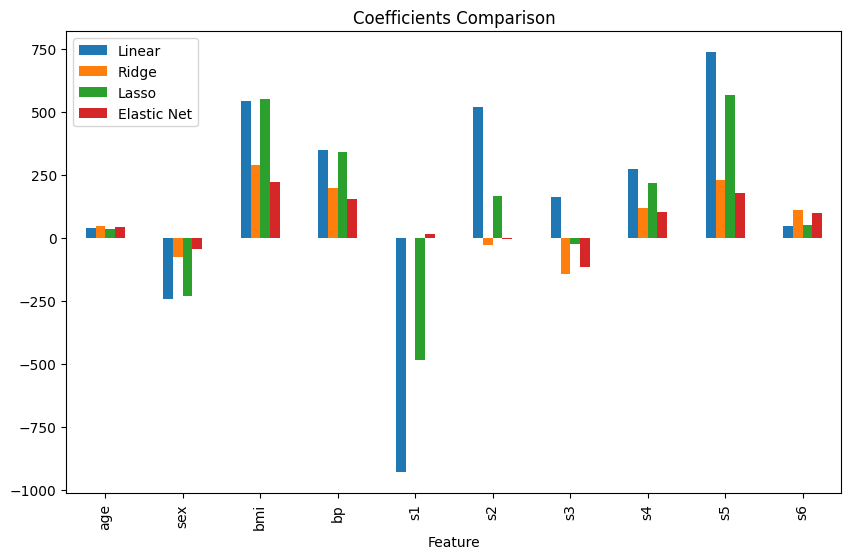

In [20]:
#Plot coefficients
coef_df.set_index('Feature').plot(kind='bar', figsize=(10, 6))
plt.title('Coefficients Comparison')
plt.show()


# MY OBSERVATIONS

1.  ** Linar Regression Baseline**: he coefficients here represent the raw, unregularized weights assigned to each feature. We can see some very large magnitudes
2.   **Ridge Regression (L2 Regularization):** Ridge regression shrinks coefficients towards zero but rarely makes them exactly zero. We observe a significant reduction in the magnitude of many coefficients compared to linear regression.
1.   **Lasso Regression (L1 Regularization):** Lasso is known for its ability to perform feature selection by shrinking some coefficients all the way to zero. With alpha=0.01, we see that while many coefficients are shrunk, none are exactly zero in this particular output, but their magnitudes are generally smaller than Linear Regression.
2.   **Elastic Net Regression: **Elastic Net combines both L1 and L2 penalties. It balances the feature selection of Lasso with the coefficient shrinkage of Ridge. We can see that the coefficients for Elastic Net (with alpha=0.01, l1_ratio=0.5) generally fall somewhere between Lasso and Ridge.



# CONCLUSION

Ridge and Elastic Net generally produced smaller coefficients across the board, which can lead to more stable models and less sensitivity to individual feature values, especially for correlated features. Lasso, while intended for feature selection, still kept most features, just with reduced coefficients at this alpha value. The s1 and s2 features, which had very high coefficients in Linear Regression, were most heavily impacted by the regularization techniques, particularly by Ridge and Elastic Net, suggesting they might have been prone to overfitting in the unregularized model.